# ISC 度量学习特征提取训练

## 概述
- **基础模型**: EfficientNet-B3（可替换为 ResNet-50 等标准 backbone）
- **训练方式**: 度量学习——使用 SubCenter ArcFace 边界损失训练全局特征
- **损失函数**: ArcFace / CosFace margin loss，将特征映射到超球面
- **输出**: L2 归一化的全局特征向量
- **模型保存**: 最佳轮次保存 backbone + margin head 权重

## 1. 环境配置与超参数

In [1]:
import os, math, time, json, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from matplotlib import pyplot as plt
import timm

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# ── 路径配置 ──
IMAGE_ROOT = r'../image-matching-challenge-2025/train'
CHECKPOINT_DIR = r'../checkpoints/isc'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── 下载 EfficientNet 预训练权重到本地 ──
TIMM_CACHE = os.path.abspath('../models/timm')
os.makedirs(TIMM_CACHE, exist_ok=True)
EFFICIENTNET_WEIGHT = os.path.join(TIMM_CACHE, 'tf_efficientnet_b3_ns-9d44bf68.pth')

def download_efficientnet_weights(url, dest_path, chunk_size=8*1024*1024):
    import urllib.request
    dest_path = os.path.abspath(dest_path)
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    req = urllib.request.Request(url, method='HEAD')
    with urllib.request.urlopen(req, timeout=30) as resp:
        total_size = int(resp.headers.get('Content-Length', 0))
    print(f'Remote file size: {total_size / (1024**2):.1f} MB')
    downloaded = 0
    if os.path.exists(dest_path):
        downloaded = os.path.getsize(dest_path)
        if downloaded >= total_size:
            print(f'File already complete: {dest_path}')
            return
        elif downloaded > 0:
            print(f'Resuming from {downloaded/(1024**2):.1f} / {total_size/(1024**2):.1f} MB')
    mode = 'ab' if downloaded > 0 else 'wb'
    req = urllib.request.Request(url)
    if downloaded > 0:
        req.add_header('Range', f'bytes={downloaded}-')
    max_retries = 3
    for attempt in range(max_retries):
        try:
            with urllib.request.urlopen(req, timeout=60) as resp:
                with open(dest_path, mode) as f:
                    while True:
                        chunk = resp.read(chunk_size)
                        if not chunk: break
                        f.write(chunk)
                        downloaded += len(chunk)
                        pct = downloaded / total_size * 100
                        print(f'\r  Downloading... {downloaded/(1024**2):.1f} / {total_size/(1024**2):.1f} MB ({pct:.1f}%)', end='', flush=True)
            print(f'\nDownload complete: {dest_path}')
            return
        except Exception as e:
            print(f'\nDownload failed (attempt {attempt+1}/{max_retries}): {e}')
            if attempt < max_retries - 1:
                time.sleep(3)
                if os.path.exists(dest_path): downloaded = os.path.getsize(dest_path)
                mode = 'ab' if downloaded > 0 else 'wb'
                req = urllib.request.Request(url)
                if downloaded > 0: req.add_header('Range', f'bytes={downloaded}-')
            else:
                raise RuntimeError(f'Failed to download after {max_retries} attempts')

if not os.path.exists(EFFICIENTNET_WEIGHT):
    url = 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_b3_ns-9d44bf68.pth'
    download_efficientnet_weights(url, EFFICIENTNET_WEIGHT)

# ── 训练超参数 ──
IMG_SIZE = 384                # EfficientNet 标准输入
BATCH_SIZE = 64
EPOCHS = 80
EARLY_STOP_PATIENCE = 10      # 早停
BASE_LR = 1e-3
WEIGHT_DECAY = 1e-4
FEATURE_DIM = 512

# ArcFace 参数
ARC_MARGIN = 0.5
ARC_SCALE = 30.0
SUB_CENTERS = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU: {gpu_name} ({total_mem:.1f} GB)')

GPU: NVIDIA GeForce RTX 5090 (31.4 GB)


## 2. Backbone & ArcFace Head

使用 EfficientNet 作为 backbone，在其上增加 SubCenter ArcFace head。
SubCenter ArcFace 为每个类学习 K 个子中心，缓解类内方差大的问题。

In [2]:
class GeM(nn.Module):
    """Generalized Mean Pooling：可学习的 p-norm 池化"""

    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            kernel_size=(x.size(-2), x.size(-1))
        ).pow(1.0 / self.p).flatten(1)


class ISCBackbone(nn.Module):
    """EfficientNet + GeM pooling + FC projection"""

    def __init__(self, model_name='tf_efficientnet_b3_ns', feature_dim=FEATURE_DIM):
        super().__init__()
        self.encoder = timm.create_model(model_name, pretrained=False, num_classes=0)
        state_dict = torch.load(EFFICIENTNET_WEIGHT, map_location='cpu', weights_only=True)
        self.encoder.load_state_dict(state_dict, strict=False)
        print(f'Loaded pretrained weights from: {EFFICIENTNET_WEIGHT}')
        encoder_dim = self.encoder.num_features
        self.pooling = GeM()
        self.fc = nn.Linear(encoder_dim, feature_dim)
        self.bn = nn.BatchNorm1d(feature_dim)

    def forward(self, x):
        features = self.encoder.forward_features(x)
        pooled = self.pooling(features)
        embedding = self.fc(pooled)
        embedding = self.bn(embedding)
        embedding = F.normalize(embedding, p=2, dim=-1)
        return embedding


class SubCenterArcFace(nn.Module):
    """SubCenter ArcFace: 每类 K 个子中心，取最近子中心做 margin loss"""

    def __init__(self, in_features, num_classes, margin=ARC_MARGIN, scale=ARC_SCALE, k=SUB_CENTERS):
        super().__init__()
        self.margin = margin
        self.scale = scale
        self.k = k
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes * k, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, labels):
        cosine_all = F.linear(features, F.normalize(self.weight, p=2, dim=-1))
        cosine_all = cosine_all.view(features.size(0), -1, self.k)
        cosine, _ = cosine_all.max(dim=-1)
        sine = torch.sqrt(1.0 - cosine ** 2 + 1e-7)
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.scale
        return F.cross_entropy(output, labels)


backbone = ISCBackbone(model_name='tf_efficientnet_b3_ns', feature_dim=FEATURE_DIM).to(device)
print(f'ISC backbone loaded. Feature dim: {FEATURE_DIM}')

/root/miniconda3/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(


Loaded pretrained weights from: /root/Image-Matching-and-3D-Reconstruction/models/timm/tf_efficientnet_b3_ns-9d44bf68.pth
ISC backbone loaded. Feature dim: 512


## 3. 数据加载

度量学习需要类别标签（场景 ID）。如果无真值标签，可使用聚类生成伪标签。
数据增强采用轻量级策略（避免破坏几何结构）。

In [3]:
class MetricLearningDataset(Dataset):
    """度量学习数据集：每张图片 + 场景标签"""

    def __init__(self, root, scene_labels=None, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.scene_labels = scene_labels

        image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        self.paths = sorted(
            p for p in self.root.rglob('*')
            if p.is_file() and p.suffix.lower() in image_exts
        )

        # 构建标签映射
        if self.scene_labels:
            unique_scenes = sorted(set(self.scene_labels.values()))
            self.scene_to_id = {s: i for i, s in enumerate(unique_scenes)}
            self.labels = [self.scene_to_id[self.scene_labels.get(p.name, p.stem)]
                           for p in self.paths]
        else:
            # 无标签时每个图片自成一类（作为 fallback，实际应使用伪标签）
            self.labels = list(range(len(self.paths)))

        self.num_classes = len(set(self.labels))
        print(f'Loaded {len(self.paths)} images, {self.num_classes} classes')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx], str(p)


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

scene_labels = None
label_file = Path(IMAGE_ROOT) / 'scene_labels.json'
if label_file.exists():
    with open(label_file) as f:
        scene_labels = json.load(f)
    print(f'Loaded scene labels for {len(scene_labels)} images')
else:
    print('WARNING: No scene labels found. Each image treated as its own class.')
    print('Consider generating pseudo-labels via clustering before training.')

dataset = MetricLearningDataset(IMAGE_ROOT, scene_labels=scene_labels, transform=train_transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)
print(f'Batches per epoch: {len(loader)}, Classes: {dataset.num_classes}')

Consider generating pseudo-labels via clustering before training.
Loaded 1945 images, 1945 classes
Batches per epoch: 30, Classes: 1945


## 4. ArcFace Head & 优化器

SubCenter ArcFace head 需要知道类别数量。优化器分两组：backbone 和 head 使用不同学习率。

In [4]:
num_classes = dataset.num_classes
arcface_head = SubCenterArcFace(
    in_features=FEATURE_DIM,
    num_classes=num_classes,
    margin=ARC_MARGIN,
    scale=ARC_SCALE,
    k=SUB_CENTERS
).to(device)

# 分组学习率：head 用更大学习率
optimizer = torch.optim.AdamW([
    {'params': backbone.parameters(), 'lr': BASE_LR},
    {'params': arcface_head.parameters(), 'lr': BASE_LR * 5},
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')
print(f'ArcFace head: {num_classes} classes x {SUB_CENTERS} sub-centers, {FEATURE_DIM}-dim')

ArcFace head: 1945 classes x 3 sub-centers, 512-dim


## 5. 训练循环

度量学习训练：前向 → ArcFace loss → 反向传播。监控 loss 和特征分布。

In [5]:
best_loss = float('inf')
history = {'train_loss': [], 'lr': []}
early_stop_counter = 0

for epoch in range(EPOCHS):
    backbone.train()
    arcface_head.train()
    epoch_loss = 0.0
    t0 = time.time()

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for imgs, labels, _ in pbar:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type='cuda', enabled=device.type == 'cuda'):
            features = backbone(imgs)
            loss = arcface_head(features, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    avg_loss = epoch_loss / len(loader)
    history['train_loss'].append(avg_loss)
    history['lr'].append(scheduler.get_last_lr()[0])
    t1 = time.time()

    improved = avg_loss < best_loss
    if improved:
        best_loss = avg_loss
        early_stop_counter = 0
        ckpt = {
            'epoch': epoch + 1,
            'backbone_state': backbone.state_dict(),
            'arcface_head_state': arcface_head.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'loss': avg_loss,
        }
        torch.save(ckpt, os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Time: {t1-t0:.1f}s | LR: {scheduler.get_last_lr()[0]:.2e} | * Best *')
    else:
        early_stop_counter += 1
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Time: {t1-t0:.1f}s | LR: {scheduler.get_last_lr()[0]:.2e} | No improvement ({early_stop_counter}/{EARLY_STOP_PATIENCE})')
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

print(f'\nTraining complete. Best loss: {best_loss:.4f}')

import pandas as pd
df_loss = pd.DataFrame({
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'lr': history['lr'],
})
csv_path = os.path.join(CHECKPOINT_DIR, 'training_loss.csv')
df_loss.to_csv(csv_path, index=False)
print(f'Loss history saved to {csv_path}')

Epoch 1/80: 100%|██████████| 30/30 [00:47<00:00,  1.59s/it, loss=22.9676]


Epoch 1/80 | Loss: 22.9441 | Time: 47.6s | LR: 1.00e-03 | * Best *


Epoch 2/80: 100%|██████████| 30/30 [00:38<00:00,  1.29s/it, loss=22.0664]


Epoch 2/80 | Loss: 21.4869 | Time: 38.8s | LR: 9.98e-04 | * Best *


Epoch 3/80: 100%|██████████| 30/30 [00:40<00:00,  1.34s/it, loss=20.0686]


...

Epoch 75/80 | Loss: 0.0980 | Time: 39.0s | LR: 1.06e-05 | No improvement (8/10)


Epoch 76/80: 100%|██████████| 30/30 [00:40<00:00,  1.35s/it, loss=0.1235]


Epoch 76/80 | Loss: 0.1241 | Time: 40.4s | LR: 7.15e-06 | No improvement (9/10)


Epoch 77/80: 100%|██████████| 30/30 [00:40<00:00,  1.34s/it, loss=0.0921]


Epoch 77/80 | Loss: 0.0932 | Time: 40.4s | LR: 4.46e-06 | No improvement (10/10)
Early stopping triggered at epoch 77

Training complete. Best loss: 0.0879
Loss history saved to ../checkpoints/isc/training_loss.csv


## 6. 训练曲线

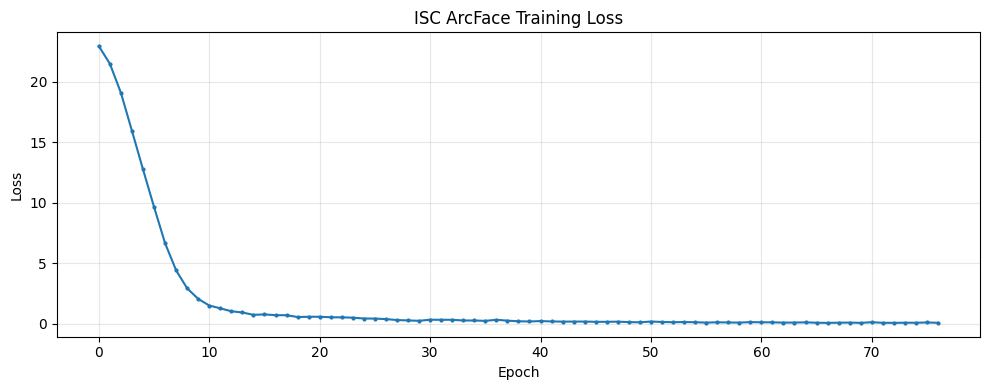

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], marker='o', markersize=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ISC ArcFace Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curve.png'), dpi=150)
plt.show()

## 7. 全局特征推理函数

用于后续 Phase 2 图像检索时批量提取 ISC 特征。仅使用 backbone，去掉 ArcFace head。

In [7]:
@torch.no_grad()
def extract_isc_features(backbone, image_paths, transform, batch_size=32):
    """
    批量提取 ISC 全局特征

    Args:
        backbone: ISCBackbone (EfficientNet + GeM + FC)
        image_paths: list of image paths
        transform: preprocessing transform
        batch_size: inference batch size
    Returns:
        features: (N, FEATURE_DIM) L2-normalized features
    """
    backbone.eval()
    features_list = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]
        imgs = []
        for p in batch_paths:
            im = Image.open(p).convert('RGB')
            imgs.append(transform(im).unsqueeze(0))
        x = torch.cat(imgs, dim=0).to(device)
        feat = backbone(x)
        features_list.append(feat.cpu())

    features = torch.cat(features_list, dim=0)
    return features


inference_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_best_isc_model(checkpoint_dir, backbone, device):
    """加载最佳 checkpoint（仅 backbone 用于推理）"""
    ckpt_path = os.path.join(checkpoint_dir, 'best_model.pth')
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f'Best model not found at {ckpt_path}')
    ckpt = torch.load(ckpt_path, map_location=device)
    backbone.load_state_dict(ckpt['backbone_state'])
    backbone.eval()
    print(f'Loaded best model from epoch {ckpt["epoch"]}, loss={ckpt["loss"]:.4f}')
    return backbone


print('Inference functions ready.')

Inference functions ready.
